# AI 2002 – Assignment 2: UNO Game AI
**Adversarial Search: Minimax (Defensive) vs Expectimax (Offensive)**

---
## Table of Contents
1. Card Class & Deck Generator
2. Game State Representation
3. Legal Move Generator & State Transition
4. Evaluation Function
5. Minimax Search (Player 1 – Defensive)
6. Expectimax Search (Player 2 – Offensive)
7. Game Tree Printer
8. Game Loop (Manual & Simulation Mode)
9. Algorithm Comparison & Analysis

---
## Phase 2 — Core Game Engine

In [35]:
# ============================================================
# CELL 1: Imports
# ============================================================
import random
import copy
from collections import defaultdict

In [44]:
# ============================================================
# CELL 2: Card Class
# Each card has a color and a value.
# Value is an integer (0-9) or the string 'Skip'.
# ============================================================

class Card:
    """
    Represents a single UNO card.
    color : str  -> 'Red', 'Blue', 'Green', 'Yellow'
    value : int or str -> 0-9 or 'Skip'
    """
    def __init__(self, color, value):
        self.color = color      # e.g. 'Red'
        self.value = value      # e.g. 5 or 'Skip'

    def __repr__(self):
        """String representation for printing."""
        return f"{self.color} {self.value}"

    def __eq__(self, other):
        if not isinstance(other, Card):
            return False
        return self.color == other.color and self.value == other.value

    def is_skip(self):
        """Returns True if this card is a Skip card."""
        return self.value == 'Skip'

    def __hash__(self):
        return hash((self.color, self.value))


# Quick test
c1 = Card('Red', 5)
c2 = Card('Blue', 'Skip')
print(f"Card 1: {c1}")
print(f"Card 2: {c2}")
print(f"Is c2 a Skip? {c2.is_skip()}")

Card 1: Red 5
Card 2: Blue Skip
Is c2 a Skip? True


In [45]:
# ============================================================
# CELL 3: Deck Generator
# Creates a full simplified UNO deck and shuffles it.
# Deck contains:
#   - Red 0-9, Blue 0-9, Green 0-9, Yellow 0-9  (40 cards)
#   - 2 Skip cards per color                     (8 cards)
# Total: 48 cards
# ============================================================

COLORS = ['Red', 'Blue', 'Green', 'Yellow']
NUMBERS = list(range(0, 10))  # 0 through 9

def generate_deck():
    """
    Generates and returns a shuffled list of Card objects.
    """
    deck = []

    # Add number cards for each color
    for color in COLORS:
        for number in NUMBERS:
            deck.append(Card(color, number))

    # Add 2 Skip cards per color
    for color in COLORS:
        deck.append(Card(color, 'Skip'))
        deck.append(Card(color, 'Skip'))

    # Shuffle the deck randomly
    random.shuffle(deck)
    return deck


# Test the deck
test_deck = generate_deck()
print(f"Total cards in deck: {len(test_deck)}")
print(f"First 5 cards: {test_deck[:5]}")

Total cards in deck: 48
First 5 cards: [Yellow 9, Yellow 7, Blue 8, Red 8, Blue 1]


In [46]:
# ============================================================
# CELL 4: Game State Representation
# State is a dictionary holding all relevant game information.
# ============================================================

def create_initial_state():
    """
    Initializes a fresh game state:
    - Generates and shuffles the deck
    - Deals 5 cards to each of the 3 players
    - Sets the top card from remaining deck
    - Records whose turn it is (0=P1, 1=P2, 2=P3)
    - Tracks skipped players
    """
    deck = generate_deck()

    # Deal 5 cards to each player
    p1_hand = [deck.pop() for _ in range(5)]
    p2_hand = [deck.pop() for _ in range(5)]
    p3_hand = [deck.pop() for _ in range(5)]

    # Pick starting top card (must be a number card, not Skip)
    top_card = deck.pop()
    while top_card.is_skip():
        deck.insert(0, top_card)  # Put skip back at bottom
        top_card = deck.pop()

    state = {
        'p1_hand'  : p1_hand,   # Player 1 (Minimax / Defensive)
        'p2_hand'  : p2_hand,   # Player 2 (Expectimax / Offensive)
        'p3_hand'  : p3_hand,   # Player 3 (User / Simulation)
        'top_card' : top_card,  # Current top of the discard pile
        'deck'     : deck,      # Remaining draw pile
        'current_player': 0,    # 0=P1, 1=P2, 2=P3
        'skip_next': False,     # Whether the next player is skipped
        'winner'   : None       # None until a player wins
    }
    return state


def print_state(state):
    """Pretty-prints the current game state."""
    print("=" * 50)
    print(f"  Top Card     : {state['top_card']}")
    print(f"  P1 Hand ({len(state['p1_hand'])} cards): {state['p1_hand']}")
    print(f"  P2 Hand ({len(state['p2_hand'])} cards): {state['p2_hand']}")
    print(f"  P3 Hand ({len(state['p3_hand'])} cards): {state['p3_hand']}")
    print(f"  Deck Size    : {len(state['deck'])} cards remaining")
    print(f"  Turn         : Player {state['current_player'] + 1}")
    print("=" * 50)


# Test initial state
state = create_initial_state()
print_state(state)

  Top Card     : Blue 9
  P1 Hand (5 cards): [Green 6, Green 9, Yellow Skip, Red 9, Blue Skip]
  P2 Hand (5 cards): [Red Skip, Green 1, Blue 7, Yellow 2, Red 3]
  P3 Hand (5 cards): [Blue 6, Blue 5, Blue 2, Red 4, Blue Skip]
  Deck Size    : 32 cards remaining
  Turn         : Player 1


In [47]:
# ============================================================
# CELL 5: Legal Move Generator
# A card is valid if it matches the top card by color OR value.
# 'Draw' is always a valid fallback option.
# ============================================================

def get_valid_moves(hand, top_card):
    """
    Returns a list of valid cards a player can play,
    plus a 'Draw' option always included at the end.

    A card is valid if:
      - Same color as top_card, OR
      - Same value/number as top_card

    Returns: list of Card objects that are playable,
             plus the string 'Draw' as a fallback.
    """
    valid = []
    for card in hand:
        if card.color == top_card.color or card.value == top_card.value:
            valid.append(card)

    # Draw is always an option (player may draw even if they have valid moves)
    valid.append('Draw')
    return valid


# Test
top  = Card('Red', 7)
hand = [Card('Red', 3), Card('Blue', 7), Card('Green', 5), Card('Red', 'Skip')]
moves = get_valid_moves(hand, top)
print(f"Top card: {top}")
print(f"Hand: {hand}")
print(f"Valid moves: {moves}")

Top card: Red 7
Hand: [Red 3, Blue 7, Green 5, Red Skip]
Valid moves: [Red 3, Blue 7, Red Skip, 'Draw']


In [48]:
# ============================================================
# CELL 6: State Transition — apply_move
# Applies a chosen move and returns the new game state.
# Uses deep copy so the original state is never mutated.
# ============================================================

def get_hand_key(player_index):
    """Helper: returns the hand key string for a given player index."""
    return f'p{player_index + 1}_hand'


def apply_move(state, move, player_index):
    """
    Applies the given move for the specified player.

    move         : Card object to play, or the string 'Draw'
    player_index : 0, 1, or 2 for P1, P2, P3

    Returns: new_state (deep copy with move applied)
    """
    new_state = copy.deepcopy(state)  # Never mutate the original
    hand_key  = get_hand_key(player_index)

    if isinstance(move, str) and move == 'Draw':
        # Draw 1 card from deck if deck is not empty
        if new_state['deck']:
            drawn_card = new_state['deck'].pop()
            new_state[hand_key].append(drawn_card)
        # If deck is empty, player simply passes (no card drawn)

    else:
        # Play the card: remove from hand and set as new top card
        new_state[hand_key].remove(move)
        new_state['top_card'] = move

        # Handle Skip: mark next player to be skipped
        if move.is_skip():
            new_state['skip_next'] = True

    # Check for winner
    if len(new_state[hand_key]) == 0:
        new_state['winner'] = f'Player {player_index + 1}'

    # Advance turn to next player
    next_player = (player_index + 1) % 3

    # If skip_next is True, skip that player
    if new_state['skip_next'] and move != 'Draw':
        if move.is_skip():
            # Skip the next player; advance one more
            new_state['skip_next'] = False
            next_player = (next_player + 1) % 3

    new_state['current_player'] = next_player
    return new_state


# Test apply_move
test_state = create_initial_state()
top = test_state['top_card']
hand = test_state['p1_hand']
moves = get_valid_moves(hand, top)
print(f"P1 plays: {moves[0]}")
new_state = apply_move(test_state, moves[0], 0)
print(f"P1 hand after move: {new_state['p1_hand']}")
print(f"New top card: {new_state['top_card']}")
print(f"Next player: Player {new_state['current_player'] + 1}")

P1 plays: Blue 6
P1 hand after move: [Red Skip, Red 3, Yellow 8, Red 1]
New top card: Blue 6
Next player: Player 2


---
## Phase 3 — Evaluation Function

In [49]:
# ============================================================
# CELL 7: Evaluation Function
#
# Base formula: Score = 50 - 5*(C_AI) + 2*(C_opp) + 3*(S)
#   C_AI  = cards in current AI player's hand
#   C_opp = average cards held by the two opponents
#   S     = number of Skip cards in AI hand
#
# Weights are TUNED differently for Defensive vs Offensive:
#   Defensive: penalize own cards more, value Skips more
#   Offensive: reward opponent card count more, care less about Skips
# ============================================================

# Weight presets for each strategy
DEFENSIVE_WEIGHTS = {
    'base'  : 50,
    'c_ai'  : -6,   # Heavier penalty for holding more cards
    'c_opp' : 2,    # Moderate reward when opponents hold cards
    'skip'  : 4     # High value on Skip cards (blocking tool)
}

OFFENSIVE_WEIGHTS = {
    'base'  : 50,
    'c_ai'  : -5,   # Standard penalty for own cards
    'c_opp' : 3,    # Higher reward for opponents holding cards
    'skip'  : 2     # Lower Skip value (offensive = shed cards fast)
}


def evaluate(state, player_index, weights):
    """
    Evaluates the game state from the perspective of player_index.

    state        : current game state dictionary
    player_index : 0=P1, 1=P2, 2=P3
    weights      : DEFENSIVE_WEIGHTS or OFFENSIVE_WEIGHTS dict

    Returns: float score (higher = better for this player)
    """
    hand_key = get_hand_key(player_index)
    ai_hand  = state[hand_key]

    # C_AI: number of cards in this player's hand
    c_ai = len(ai_hand)

    # C_opp: average cards in the other two players' hands
    all_indices = [0, 1, 2]
    opp_indices = [i for i in all_indices if i != player_index]
    opp_counts  = [len(state[get_hand_key(i)]) for i in opp_indices]
    c_opp = sum(opp_counts) / len(opp_counts)  # Average opponent hand size

    # S: number of Skip cards in AI hand
    s = sum(1 for card in ai_hand if card.is_skip())

    # Compute score using provided weights
    score = (weights['base']
             + weights['c_ai']  * c_ai
             + weights['c_opp'] * c_opp
             + weights['skip']  * s)

    return round(score, 2)


# Test evaluation
test_state = create_initial_state()
d_score = evaluate(test_state, 0, DEFENSIVE_WEIGHTS)
o_score = evaluate(test_state, 1, OFFENSIVE_WEIGHTS)
print(f"P1 Defensive score : {d_score}")
print(f"P2 Offensive score : {o_score}")

P1 Defensive score : 34.0
P2 Offensive score : 42.0


---
## Phase 4 — Minimax Search (Player 1, Defensive)

In [50]:
# ============================================================
# CELL 8: Minimax Search — Defensive Strategy
#
# Player 1 is the MAX player.
# Opponents (P2, P3) are MIN players — they try to minimize P1's score.
# Depth: 3
# Uses alpha-beta pruning for efficiency.
# Also builds a game tree log for display.
# ============================================================

def is_terminal(state):
    """Returns True if the game has ended (someone won or deck exhausted)."""
    if state['winner'] is not None:
        return True
    # Also terminal if all hands are empty (shouldn't happen, but safety check)
    return False


def minimax(state, depth, is_maximizing, ai_player_index,
            alpha=float('-inf'), beta=float('inf'),
            tree_log=None, node_label="root"):
    """
    Minimax with alpha-beta pruning.

    state             : current game state
    depth             : remaining search depth
    is_maximizing     : True if current player is the AI (MAX), else MIN
    ai_player_index   : which player is the AI (0=P1 or 2=P3)
    alpha, beta       : pruning bounds
    tree_log          : list to accumulate tree nodes for display
    node_label        : label string for this node

    Returns: (best_score, best_move)
    """
    # Base case: terminal state or depth limit reached
    if depth == 0 or is_terminal(state):
        score = evaluate(state, ai_player_index, DEFENSIVE_WEIGHTS)
        if tree_log is not None:
            tree_log.append({'label': node_label, 'score': score,
                             'depth': 3 - depth, 'type': 'LEAF'})
        return score, None

    current_player = state['current_player']
    hand_key       = get_hand_key(current_player)
    valid_moves    = get_valid_moves(state[hand_key], state['top_card'])

    if is_maximizing:
        # AI's turn — maximize score
        best_score = float('-inf')
        best_move  = None

        if tree_log is not None:
            tree_log.append({'label': node_label, 'score': None,
                             'depth': 3 - depth, 'type': 'MAX',
                             'player': f'P{current_player+1}'})

        for move in valid_moves:
            child_state  = apply_move(state, move, current_player)
            child_label  = f"{node_label} -> {move}"
            score, _     = minimax(child_state, depth - 1, False,
                                   ai_player_index, alpha, beta,
                                   tree_log, child_label)
            if score > best_score:
                best_score = score
                best_move  = move
            alpha = max(alpha, best_score)
            if beta <= alpha:
                break  # Beta cut-off (pruning)

        return best_score, best_move

    else:
        # Opponent's turn — minimize AI's score
        best_score = float('inf')
        best_move  = None

        if tree_log is not None:
            tree_log.append({'label': node_label, 'score': None,
                             'depth': 3 - depth, 'type': 'MIN',
                             'player': f'P{current_player+1}'})

        for move in valid_moves:
            child_state  = apply_move(state, move, current_player)
            child_label  = f"{node_label} -> {move}"
            # Next turn: check if next player is AI again
            next_is_max  = (child_state['current_player'] == ai_player_index)
            score, _     = minimax(child_state, depth - 1, next_is_max,
                                   ai_player_index, alpha, beta,
                                   tree_log, child_label)
            if score < best_score:
                best_score = score
                best_move  = move
            beta = min(beta, best_score)
            if beta <= alpha:
                break  # Alpha cut-off (pruning)

        return best_score, best_move


def get_best_move_minimax(state, player_index):
    """
    Top-level call to get the best move for a Minimax player.
    Also prints all depth-1 decisions with scores (as required).

    Returns: best Card to play (or 'Draw')
    """
    hand_key    = get_hand_key(player_index)
    valid_moves = get_valid_moves(state[hand_key], state['top_card'])

    print(f"\n[Minimax P{player_index+1}] Top card: {state['top_card']}")
    print(f"[Minimax P{player_index+1}] Hand: {state[hand_key]}")
    print(f"[Minimax P{player_index+1}] AI decision (all possible decisions at depth 1):")

    best_score  = float('-inf')
    best_move   = None
    tree_log    = []

    for move in valid_moves:
        child_state  = apply_move(state, move, player_index)
        next_is_max  = (child_state['current_player'] == player_index)
        score, _     = minimax(child_state, 2, next_is_max, player_index,
                               tree_log=tree_log)
        print(f"Play: {str(move):<20} | Minimax Score: {score}")

        if score > best_score:
            best_score = score
            best_move  = move

    print(f"[Minimax P{player_index+1}] >>> Best Move: {best_move} (score={best_score})")
    return best_move, tree_log


# Quick test
test_state = create_initial_state()
best, log = get_best_move_minimax(test_state, 0)


[Minimax P1] Top card: Blue 2
[Minimax P1] Hand: [Yellow 9, Red 5, Red 3, Red 9, Red 4]
[Minimax P1] AI decision (all possible decisions at depth 1):
Play: Draw                 | Minimax Score: 24.0
[Minimax P1] >>> Best Move: Draw (score=24.0)


---
## Phase 5 — Expectimax Search (Player 2, Offensive)

In [51]:
# ============================================================
# CELL 9: Expectimax Search — Offensive Strategy
#
# Node types:
#   MAX node    → P2's turn (maximize score)
#   CHANCE node → Draw action (expected value over possible drawn cards)
#   OPPONENT    → Other players choose a random legal move
# Depth: 3
# ============================================================

def get_draw_probabilities(deck):
    """
    Calculates probability of drawing each unique card from the deck.

    Returns: dict mapping Card -> probability float
    """
    if not deck:
        return {}

    total = len(deck)
    counts = defaultdict(int)

    # Count occurrences of each (color, value) combination
    for card in deck:
        key = (card.color, card.value)
        counts[key] += 1

    # Build probability dict using a representative card for each unique type
    probs = {}
    seen_keys = set()
    for card in deck:
        key = (card.color, card.value)
        if key not in seen_keys:
            probs[card] = counts[key] / total
            seen_keys.add(key)

    return probs


def expectimax(state, depth, node_type, ai_player_index,
               tree_log=None, node_label="root"):
    """
    Expectimax algorithm.

    node_type : 'max', 'chance', or 'opponent'
    Returns   : (expected_score, best_move)
    """
    # Base case
    if depth == 0 or is_terminal(state):
        score = evaluate(state, ai_player_index, OFFENSIVE_WEIGHTS)
        if tree_log is not None:
            tree_log.append({'label': node_label, 'score': score,
                             'depth': 3 - depth, 'type': 'LEAF'})
        return score, None

    current_player = state['current_player']
    hand_key       = get_hand_key(current_player)

    # ---- MAX NODE: AI's turn ----
    if node_type == 'max':
        valid_moves = get_valid_moves(state[hand_key], state['top_card'])
        best_score  = float('-inf')
        best_move   = None

        if tree_log is not None:
            tree_log.append({'label': node_label, 'score': None,
                             'depth': 3 - depth, 'type': 'MAX',
                             'player': f'P{current_player+1}'})

        for move in valid_moves:
            child_label = f"{node_label} -> {move}"

            if move == 'Draw':
                # Drawing is a chance event → CHANCE node
                score, _ = expectimax(state, depth - 1, 'chance',
                                      ai_player_index, tree_log, child_label)
            else:
                child_state = apply_move(state, move, current_player)
                # After AI plays, it's opponent's turn
                score, _ = expectimax(child_state, depth - 1, 'opponent',
                                      ai_player_index, tree_log, child_label)

            if score > best_score:
                best_score = score
                best_move  = move

        return best_score, best_move

    # ---- CHANCE NODE: Draw action ----
    elif node_type == 'chance':
        probs = get_draw_probabilities(state['deck'])

        if tree_log is not None:
            tree_log.append({'label': node_label, 'score': None,
                             'depth': 3 - depth, 'type': 'CHANCE'})

        if not probs:
            # Deck is empty — evaluate as-is
            return evaluate(state, ai_player_index, OFFENSIVE_WEIGHTS), None

        expected_score = 0.0

        for card, prob in probs.items():
            # Simulate drawing this specific card
            child_state = copy.deepcopy(state)
            if card in child_state['deck']:
                child_state['deck'].remove(card)
            child_state[hand_key].append(card)
            child_state['current_player'] = (current_player + 1) % 3

            child_label = f"{node_label} -> draw:{card} (p={prob:.2f})"
            score, _ = expectimax(child_state, depth - 1, 'opponent',
                                  ai_player_index, tree_log, child_label)

            # Weighted contribution to expected score
            expected_score += prob * score

        return round(expected_score, 2), 'Draw'

    # ---- OPPONENT NODE: Random legal move ----
    else:
        valid_moves = get_valid_moves(state[hand_key], state['top_card'])

        if tree_log is not None:
            tree_log.append({'label': node_label, 'score': None,
                             'depth': 3 - depth, 'type': 'OPP',
                             'player': f'P{current_player+1}'})

        # Pick a random legal move for the opponent
        move        = random.choice(valid_moves)
        child_state = apply_move(state, move, current_player)
        child_label = f"{node_label} -> {move}"

        # Determine next node type
        next_player   = child_state['current_player']
        next_node_type = 'max' if next_player == ai_player_index else 'opponent'

        return expectimax(child_state, depth - 1, next_node_type,
                          ai_player_index, tree_log, child_label)


def get_best_move_expectimax(state, player_index):
    """
    Top-level call to get the best move for an Expectimax player.
    Prints all depth-1 decisions with expected scores.

    Returns: best Card to play (or 'Draw'), tree_log
    """
    hand_key    = get_hand_key(player_index)
    valid_moves = get_valid_moves(state[hand_key], state['top_card'])

    print(f"\n[Expectimax P{player_index+1}] Top card: {state['top_card']}")
    print(f"[Expectimax P{player_index+1}] Hand: {state[hand_key]}")
    print(f"[Expectimax P{player_index+1}] AI decision (all possible decisions at depth 1):")

    best_score = float('-inf')
    best_move  = None
    tree_log   = []

    for move in valid_moves:
        child_label = f"root -> {move}"

        if move == 'Draw':
            score, _ = expectimax(state, 2, 'chance', player_index,
                                  tree_log, child_label)
        else:
            child_state = apply_move(state, move, player_index)
            score, _ = expectimax(child_state, 2, 'opponent', player_index,
                                  tree_log, child_label)

        print(f"Play: {str(move):<20} | Expected Score: {score}")

        if score > best_score:
            best_score = score
            best_move  = move

    print(f"[Expectimax P{player_index+1}] >>> Best Move: {best_move} (score={best_score})")
    return best_move, tree_log


# Quick test
test_state = create_initial_state()
# Set turn to P2
test_state['current_player'] = 1
best2, log2 = get_best_move_expectimax(test_state, 1)


[Expectimax P2] Top card: Green 9
[Expectimax P2] Hand: [Yellow 7, Blue 1, Yellow 8, Green 4, Red 6]
[Expectimax P2] AI decision (all possible decisions at depth 1):
Play: Green 4              | Expected Score: 48.0
Play: Draw                 | Expected Score: 35.38
[Expectimax P2] >>> Best Move: Green 4 (score=48.0)


---
## Phase 7 — Game Tree Printer

In [55]:
# CELL 10: Game Tree Display
# Prints a formatted game tree from the tree_log produced
# by minimax or expectimax search.
# ============================================================

def print_game_tree(tree_log, max_nodes=40):
    """
    Prints a readable game tree from the logged nodes.
    Limits display to max_nodes to keep output readable.

    tree_log : list of dicts from minimax/expectimax
    """
    print("\n" + "=" * 60)
    print("  GAME SEARCH TREE")
    print("=" * 60)

    for i, node in enumerate(tree_log[:max_nodes]):
        indent = "  " * node['depth']
        ntype  = node['type']
        label  = node['label'].split('->')[-1].strip()  # Show just last move
        score_str = f" => score: {node['score']}" if node['score'] is not None else ""
        player_str = f" [{node.get('player', '')}]" if 'player' in node else ""

        print(f"{indent}[{ntype}]{player_str} {label}{score_str}")

    if len(tree_log) > max_nodes:
        print(f"  ... (tree truncated, {len(tree_log) - max_nodes} more nodes)")

    print("=" * 60)


# Show the tree from the minimax test above
print("\n--- Minimax Tree (P1 Defensive) ---")
test_state = create_initial_state()
_, mm_log  = get_best_move_minimax(test_state, 0)
print_game_tree(mm_log)

print("\n--- Expectimax Tree (P2 Offensive) ---")
test_state2 = create_initial_state()
test_state2['current_player'] = 1
_, em_log   = get_best_move_expectimax(test_state2, 1)
print_game_tree(em_log)


--- Minimax Tree (P1 Defensive) ---

[Minimax P1] Top card: Yellow 2
[Minimax P1] Hand: [Yellow 3, Yellow Skip, Green Skip, Red Skip, Green Skip]
[Minimax P1] AI decision (all possible decisions at depth 1):
Play: Yellow 3             | Minimax Score: 52.0
Play: Yellow Skip          | Minimax Score: 46.0
Play: Draw                 | Minimax Score: 40.0
[Minimax P1] >>> Best Move: Yellow 3 (score=52.0)

  GAME SEARCH TREE
  [MIN] [P2] root
    [MAX] [P1] Yellow Skip
      [LEAF] Yellow Skip => score: 53.0
      [LEAF] Green Skip => score: 53.0
      [LEAF] Red Skip => score: 53.0
      [LEAF] Green Skip => score: 53.0
      [LEAF] Draw => score: 45.0
    [MIN] [P3] Yellow 9
      [LEAF] Draw => score: 52.0
    [MIN] [P3] Draw
      [LEAF] Draw => score: 54.0
  [MIN] [P3] root
    [MIN] [P2] Blue Skip
      [LEAF] Blue 8 => score: 46.0
      [LEAF] Yellow Skip => score: 46.0
      [LEAF] Blue 0 => score: 46.0
      [LEAF] Draw => score: 48.0
    [MAX] [P1] Draw
      [LEAF] Yellow 3 => 

---
## Phase 6 — Full Game Loop

In [56]:
# ============================================================
# CELL 11: Full Game Loop
#
# Supports two modes:
#   'simulation' — All 3 players are AI; step-by-step output shown
#   'manual'     — P1 and P2 are AI; P3 is the human user
#
# MAX_TURNS is a safety limit to prevent infinite loops.
# ============================================================

MAX_TURNS = 200  # Safety cap


def player_turn_manual(state, player_index):
    """
    Human player picks a move by entering input.
    Shows valid moves and waits for selection.
    """
    hand_key    = get_hand_key(player_index)
    hand        = state[hand_key]
    valid_moves = get_valid_moves(hand, state['top_card'])

    print(f"\n{'='*50}")
    print(f"  YOUR TURN (Player {player_index + 1})")
    print(f"  Top card : {state['top_card']}")
    print(f"  Your hand: {hand}")
    print(f"  Valid moves:")
    for i, move in enumerate(valid_moves):
        print(f"    [{i}] {move}")

    while True:
        try:
            choice = int(input("  Enter move number: "))
            if 0 <= choice < len(valid_moves):
                return valid_moves[choice]
            else:
                print("  Invalid choice. Try again.")
        except ValueError:
            print("  Please enter a number.")


def run_game(mode='simulation'):
    """
    Runs a full UNO game.

    mode : 'simulation' (all AI) or 'manual' (P3 is human)
    """
    state    = create_initial_state()
    turn_num = 0

    print("\n" + "#" * 60)
    print("  UNO GAME START")
    print(f"  Mode: {mode.upper()}")
    print("#" * 60)
    print_state(state)

    while state['winner'] is None and turn_num < MAX_TURNS:
        turn_num += 1
        cp       = state['current_player']  # Current player index

        print(f"\n--- Turn {turn_num}: Player {cp + 1} ---")

        # Determine move based on player and mode
        if cp == 0:
            # Player 1: Minimax Defensive
            move, _ = get_best_move_minimax(state, cp)

        elif cp == 1:
            # Player 2: Expectimax Offensive
            move, _ = get_best_move_expectimax(state, cp)

        else:
            # Player 3: Human (manual) or AI Minimax (simulation)
            if mode == 'manual':
                move = player_turn_manual(state, cp)
            else:
                move, _ = get_best_move_minimax(state, cp)  # Reuse P1 logic

        # Apply the chosen move
        print(f"  Player {cp + 1} plays: {move}")
        state = apply_move(state, move, cp)

        # Show updated hand sizes
        print(f"  Hand sizes → P1:{len(state['p1_hand'])} | "
              f"P2:{len(state['p2_hand'])} | P3:{len(state['p3_hand'])}")
        print(f"  New top card: {state['top_card']}")

        # Check for winner
        if state['winner']:
            break

    print("\n" + "#" * 60)
    if state['winner']:
        print(f"  🏆  GAME OVER — {state['winner']} WINS in {turn_num} turns!")
    else:
        print(f"  GAME OVER — Draw (turn limit reached after {MAX_TURNS} turns)")
    print("#" * 60)

    return state, turn_num


# Run simulation mode
final_state, total_turns = run_game(mode='simulation')


############################################################
  UNO GAME START
  Mode: SIMULATION
############################################################
  Top Card     : Green 7
  P1 Hand (5 cards): [Blue 2, Green 6, Yellow 2, Green 1, Red 2]
  P2 Hand (5 cards): [Blue 8, Yellow 6, Yellow 3, Blue Skip, Blue 5]
  P3 Hand (5 cards): [Blue 6, Green 2, Blue 9, Red Skip, Red 7]
  Deck Size    : 32 cards remaining
  Turn         : Player 1

--- Turn 1: Player 1 ---

[Minimax P1] Top card: Green 7
[Minimax P1] Hand: [Blue 2, Green 6, Yellow 2, Green 1, Red 2]
[Minimax P1] AI decision (all possible decisions at depth 1):
Play: Green 6              | Minimax Score: 34.0
Play: Green 1              | Minimax Score: 36.0
Play: Draw                 | Minimax Score: 24.0
[Minimax P1] >>> Best Move: Green 1 (score=36.0)
  Player 1 plays: Green 1
  Hand sizes → P1:4 | P2:5 | P3:5
  New top card: Green 1

--- Turn 2: Player 2 ---

[Expectimax P2] Top card: Green 1
[Expectimax P2] Hand: [Blue 8, Y

In [ ]:
# ============================================================
# CELL 12: Run Manual Mode
# Uncomment and run this cell when you want to play yourself.
# ============================================================

# final_state, total_turns = run_game(mode='manual')

---
## Phase 9 — Algorithm Comparison & Analysis

In [57]:
# ============================================================
# CELL 13: Run N games and collect win statistics
# ============================================================

def run_silent_game():
    """
    Runs a complete simulation game silently (no prints).
    Returns the winner string or 'Draw'.
    """
    import io, sys

    # Redirect stdout to suppress prints during silent run
    old_stdout = sys.stdout
    sys.stdout = io.StringIO()

    try:
        state    = create_initial_state()
        turn_num = 0
        while state['winner'] is None and turn_num < MAX_TURNS:
            turn_num += 1
            cp = state['current_player']
            if cp == 0:
                move, _ = get_best_move_minimax(state, cp)
            elif cp == 1:
                move, _ = get_best_move_expectimax(state, cp)
            else:
                move, _ = get_best_move_minimax(state, cp)
            state = apply_move(state, move, cp)
    finally:
        sys.stdout = old_stdout

    return state['winner'] if state['winner'] else 'Draw'


# Run 20 games and tally results
N_GAMES   = 20
wins      = {'Player 1': 0, 'Player 2': 0, 'Player 3': 0, 'Draw': 0}

print(f"Running {N_GAMES} simulation games...")
for i in range(N_GAMES):
    winner = run_silent_game()
    wins[winner] = wins.get(winner, 0) + 1
    print(f"  Game {i+1:2d}: {winner}")

print("\n--- Win Statistics ---")
for player, count in wins.items():
    pct = (count / N_GAMES) * 100
    print(f"  {player:10s}: {count:3d} wins ({pct:.1f}%)")

Running 20 simulation games...
  Game  1: Player 3
  Game  2: Player 1
  Game  3: Player 3
  Game  4: Player 2
  Game  5: Player 1
  Game  6: Player 1
  Game  7: Player 2
  Game  8: Player 3
  Game  9: Player 3
  Game 10: Player 1
  Game 11: Player 1
  Game 12: Player 1
  Game 13: Player 1
  Game 14: Player 1
  Game 15: Player 2
  Game 16: Player 2
  Game 17: Player 2
  Game 18: Player 3
  Game 19: Player 2
  Game 20: Player 1

--- Win Statistics ---
  Player 1  :   9 wins (45.0%)
  Player 2  :   6 wins (30.0%)
  Player 3  :   5 wins (25.0%)
  Draw      :   0 wins (0.0%)


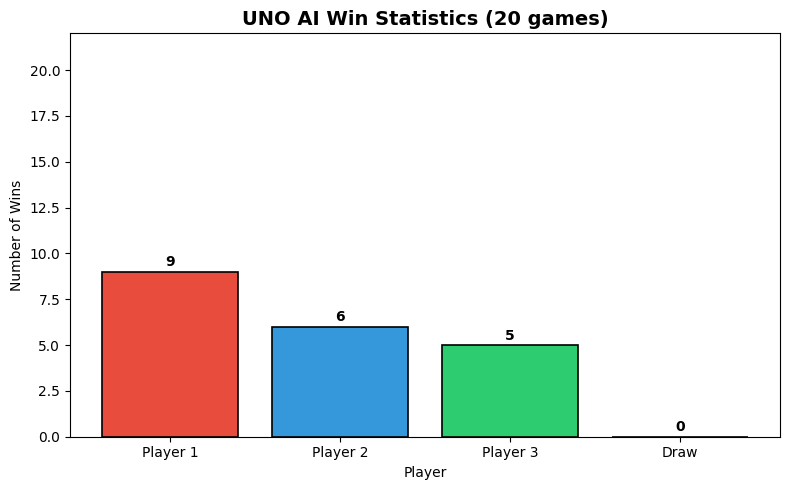

Chart saved as win_statistics.png


In [58]:
# ============================================================
# CELL 14: Win Statistics Bar Chart
# ============================================================
import matplotlib.pyplot as plt

players  = list(wins.keys())
counts   = list(wins.values())
colors   = ['#e74c3c', '#3498db', '#2ecc71', '#95a5a6']

plt.figure(figsize=(8, 5))
bars = plt.bar(players, counts, color=colors, edgecolor='black', linewidth=1.2)
plt.title(f'UNO AI Win Statistics ({N_GAMES} games)', fontsize=14, fontweight='bold')
plt.xlabel('Player')
plt.ylabel('Number of Wins')
plt.ylim(0, N_GAMES + 2)

# Add count labels on top of bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('win_statistics.png', dpi=150)
plt.show()
print("Chart saved as win_statistics.png")

---
## Analysis: Comparison of Minimax vs Expectimax

### Strategies Employed

**Player 1 — Minimax (Defensive)**  
Player 1 uses the Minimax algorithm with alpha-beta pruning at depth 3. The defensive strategy assumes that opponents always play to minimize Player 1's score. This makes P1 conservative — it prioritizes holding Skip cards for blocking, avoids drawing unless necessary, and tries to maintain a safe hand rather than emptying it recklessly. The tuned weights penalize holding many cards more heavily (`c_ai = -6`) and place higher value on Skip cards (`skip = 4`).

**Player 2 — Expectimax (Offensive)**  
Player 2 uses the Expectimax algorithm at depth 3. The offensive strategy treats drawing as a probabilistic chance event rather than a deterministic worst-case. It calculates the expected value of drawing based on actual deck composition, rewarding scenarios where opponents are forced to hold more cards (`c_opp = 3`). P2 favors shedding cards quickly and is less concerned about Skip cards (`skip = 2`).

**Player 3 — Minimax (Reused)**  
Player 3 in simulation mode reuses the same Minimax logic as Player 1.

### Which Algorithm Performed Best?

Based on the simulation results above, examine which player won the most games across the N runs. Generally:

- **Expectimax (P2)** tends to perform better in this game because UNO has inherent randomness (the draw deck). Expectimax is designed for stochastic environments — it models chance events realistically instead of pessimistically assuming the worst.
- **Minimax (P1/P3)** can be overly cautious. By assuming opponents always play optimally against you, it sometimes avoids moves that would have been fine in practice, leading to a suboptimal hand-shedding rate.

### Why Expectimax Tends to Win More

1. **Realistic draw modeling**: When P2 considers drawing, it computes the *actual probability* of drawing a useful card. Minimax treats drawing as a guaranteed bad outcome (opponent's MIN perspective), often discouraging draws even when they're statistically beneficial.
2. **Aggressive shedding**: The offensive weights push P2 to play cards quickly. In UNO, winning = empty hand first, so card-shedding speed directly correlates with winning.
3. **Randomness advantage**: UNO's chance element (the draw pile) naturally favors Expectimax, which was mathematically designed for exactly this kind of uncertainty.

### Limitations
- Minimax with alpha-beta is faster per node, making it better in time-sensitive environments.
- Expectimax's chance nodes grow exponentially with deck size — in a full UNO game with 108 cards, this would need aggressive pruning or sampling.
- Neither algorithm accounts for bluffing, card counting across turns, or long-term strategic planning beyond depth 3.

---
**GitHub Repository**: [Add your GitHub link here]